# Clasificador y Sistema de Verificación Facial Fortificado
## Rostro del Estudiante vs. Fondos y Rostros de Otras Personas

### Arquitectura Avanzada de 2 Niveles:
1. **Nivel 1 — Clasificador Neuronal con Fine-Tuning en 2 Etapas:** Red Neuronal Convolucional (MobileNetV2) con ajuste fino de capas profundas, aumentación enriquecida de datos y optimización del umbral de decisión.
2. **Nivel 2 — Sistema de Verificación Facial por Embeddings:** Comparación espacial de vectores de características mediante Similitud de Coseno / Distancia Euclidiana.

---
### Actividad Calificada e Indicadores de Evaluación (10 Puntos Totales):
- **Clase 1 (Student):** Rostro del Estudiante
- **Clase 0 (Background / Other):** Fondos vacíos, escenarios y rostros de otras personas

#### Pruebas del Modelo:
1. **Prueba 1:** Foto no vista del estudiante (`fs.jpeg` o `test1`) -> Esperado: **Estudiante** **(2 puntos)**
2. **Prueba 2:** Imagen de fondo no vista (`test2`) -> Esperado: **Fondo** **(2 puntos)**
3. **Prueba 3:** Rostro no visto de otra persona (`test3`) -> Esperado: **Fondo** **(6 puntos)**

In [ ]:
# 1. Instalación e Importación de Librerías y Métricas
%pip install opencv-python tensorflow scikit-learn matplotlib pillow

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
from sklearn.metrics.pairwise import cosine_similarity

print(f"Versión de TensorFlow: {tf.__version__}")

## 2. Preprocesamiento Avanzado y Extracción con Margen Contextual (Face + Context)
Utilizamos un detector multiescala OpenCV Haar Cascade adaptativo con un **margen adicional del 30% (padding)** para preservar la estructura facial (cabello, silueta y contexto de cabeza/cuello), asegurando que si no se detecta un rostro (como en fondos vacíos), se procese la imagen completa sin perder información.

In [ ]:
def find_dataset_dir():
    candidates = [
        os.path.abspath('Dataset'),
        r'C:\Users\User\Desktop\deber\Dataset',
        os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Dataset')
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return os.path.abspath('Dataset')

dataset_dir = find_dataset_dir()
student_dir = os.path.join(dataset_dir, 'Student')
bg_dir = os.path.join(dataset_dir, 'Background')
test_dir = os.path.join(dataset_dir, 'Test_Cases')

print(f"Directorio del Dataset: {dataset_dir}")

frontal_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def extract_face_or_image(img, target_size=(128, 128), padding_ratio=0.30):
    if img is None: return None
    h, w = img.shape[:2]
    scale = 1000.0 / max(h, w)
    small = cv2.resize(img, (int(w * scale), int(h * scale))) if scale < 1.0 else img
    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    
    faces = frontal_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=3, minSize=(20, 20))
    if len(faces) > 0:
        x, y, bw, bh = max(faces, key=lambda b: b[2]*b[3])
        if scale < 1.0:
            x, y, bw, bh = int(x / scale), int(y / scale), int(bw / scale), int(bh / scale)
        pad = int(max(bw, bh) * padding_ratio)
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(w, x + bw + pad), min(h, y + bh + pad)
        crop = img[y1:y2, x1:x2]
    else:
        crop = img
        
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crop_resized = cv2.resize(crop_rgb, target_size)
    return crop_resized

X_raw, y_raw = [], []

# Cargar Clase 1: Estudiante
for f in sorted(os.listdir(student_dir)):
    p = os.path.join(student_dir, f)
    if os.path.isfile(p):
        img = cv2.imread(p)
        proc = extract_face_or_image(img)
        if proc is not None:
            X_raw.append(proc)
            y_raw.append(1)

# Cargar Clase 0: Fondos y Otras Personas
for f in sorted(os.listdir(bg_dir)):
    p = os.path.join(bg_dir, f)
    if os.path.isfile(p):
        img = cv2.imread(p)
        proc = extract_face_or_image(img)
        if proc is not None:
            X_raw.append(proc)
            y_raw.append(0)

X_raw = np.array(X_raw, dtype='float32')
y_raw = np.array(y_raw, dtype='int32')

print(f"Dataset Total Cargado: {len(X_raw)} imágenes")
print(f"  - Estudiante (Clase 1): {np.sum(y_raw == 1)}")
print(f"  - Fondo / Otras Personas (Clase 0): {np.sum(y_raw == 0)}")

## 3. División Rigurosa del Dataset (Train 70% / Validation 15% / Test 15%)
Para evitar la fuga de datos (data leakage) y garantizar una prueba rigurosa sin sesgos de sobreajuste, realizamos una división estratificada en tres subconjuntos totalmente independientes.

In [ ]:
# Primera división: Train (70%) y Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=42, stratify=y_raw
)

# Segunda división: Validation (15%) y Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Imágenes de Entrenamiento (Train 70%): {len(X_train)}")
print(f"Imágenes de Validación (Val 15%):     {len(X_val)}")
print(f"Imágenes de Prueba Libre (Test 15%):  {len(X_test)}")

## 4. Aumentación Enriquecida de Datos (Rich Data Augmentation)
Dada la dimensión reducida del conjunto original, construimos una tubería de aumentación de datos que simula variaciones de iluminación, rotación facial, acercamientos, contraste y traslación espacial.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.20),
    layers.RandomContrast(0.20),
    layers.RandomBrightness(0.20),
    layers.RandomTranslation(0.10, 0.10)
], name="rich_data_augmentation")

student_sample_idx = np.where(y_train == 1)[0][0]
sample_img = np.expand_dims(X_train[student_sample_idx], axis=0)

plt.figure(figsize=(12, 4))
for i in range(4):
    aug_img = data_augmentation(sample_img)
    plt.subplot(1, 4, i + 1)
    plt.imshow(aug_img[0].numpy().astype('uint8'))
    plt.title(f'Augmented {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Entrenamiento Etapa 1: Transfer Learning con Capas Congeladas
Construimos el modelo base sobre **MobileNetV2** preentrenado en ImageNet. Durante la Etapa 1, congelamos el cuerpo convolucional (`base_model.trainable = False`) con `training=False` para ajustar la cabeza clasificadora de alta densidad.

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

inputs = layers.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = mobilenet_preprocess(x)

base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name='embedding_gap_layer')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs, name="Stage1_Student_Classifier")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("=== INICIANDO ENTRENAMIENTO ETAPA 1 (TRANSFER LEARNING) ===")
history_stage1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=8,
    callbacks=[early_stopping],
    verbose=1
)

## 6. Entrenamiento Etapa 2: Fine-Tuning de Capas Profundas
Descongelamos las últimas 30 capas de MobileNetV2 para permitir que la red aprenda características geométricas finas y distintivas del rostro del estudiante frente a rostros similares de otras personas. Recompilamos con una tasa de aprendizaje baja (`learning_rate=1e-5`) para evitar la destrucción de los pesos preentrenados.

In [ ]:
base_model.trainable = True

# Congelar las primeras capas y mantener únicamente las últimas 30 capas entrenables
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("=== INICIANDO ENTRENAMIENTO ETAPA 2 (FINE-TUNING) ===")
history_stage2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=8,
    callbacks=[early_stopping],
    verbose=1
)

## 7. Minería de Negativos Difíciles (Hard Negative Mining)
Evaluamos la red sobre las muestras de la Clase 0 para identificar ejemplos difíciles (falsos positivos o imágenes con probabilidad > 0.20). Estos casos límite se re-incorporan con mayor peso en una micro-época de ajuste para maximizar la robustez del modelo contra engaños.

In [ ]:
# Predecir sobre imágenes de Clase 0 en el conjunto de entrenamiento
bg_train_idx = np.where(y_train == 0)[0]
preds_bg = model.predict(X_train[bg_train_idx], verbose=0).flatten()

# Encontrar hard negatives (probabilidad > 0.20 en clase 0)
hard_neg_mask = preds_bg > 0.20
hard_neg_indices = bg_train_idx[hard_neg_mask]

print(f"Se encontraron {len(hard_neg_indices)} Negativos Difíciles (Hard Negatives) en la Clase 0.")

if len(hard_neg_indices) > 0:
    # Duplicar hard negatives para re-forzar la atención del modelo
    X_hard = X_train[hard_neg_indices]
    y_hard = y_train[hard_neg_indices]
    
    X_train_hn = np.vstack([X_train, X_hard])
    y_train_hn = np.concatenate([y_train, y_hard])
    
    print("Re-entrenando 3 épocas adicionales con Hard Negatives reforzados...")
    model.fit(
        X_train_hn, y_train_hn,
        validation_data=(X_val, y_val),
        epochs=3,
        batch_size=8,
        verbose=1
    )
else:
    print("¡Excelente! No se detectaron falsos positivos significativos en la Clase 0.")

## 8. Optimización del Umbral de Decisión (Threshold Optimization)
Debido a la asimetría del problema (es mucho más grave clasificar por error a otra persona como el estudiante que rechazar por error una foto del estudiante), analizamos el comportamiento del modelo evaluando múltiples umbrales desde $0.10$ hasta $0.90$ para seleccionar el límite óptimo equilibrado cercano a 0.50.

In [ ]:
val_probs = model.predict(X_val, verbose=0).flatten()
thresholds = np.linspace(0.10, 0.90, 17)
best_threshold = 0.50
min_fpr = 1.0
best_f1 = -1.0
best_dist_05 = 1.0

print("Umbral | Precision | Recall | F1-Score | False Positive Rate")
print("----------------------------------------------------------")
for th in thresholds:
    preds = (val_probs >= th).astype(int)
    cm = confusion_matrix(y_val, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    dist_05 = abs(th - 0.50)
    
    print(f" {th:.2f}  |   {prec:.2%}  | {rec:.2%} |  {f1:.3f}   |       {fpr:.2%}")
    
    # Seleccionar umbral que minimice FPR, maximice F1 y sea el más cercano a 0.50 en caso de empate
    if (fpr < min_fpr) or (fpr == min_fpr and f1 > best_f1) or (fpr == min_fpr and f1 == best_f1 and dist_05 < best_dist_05):
        min_fpr = fpr
        best_f1 = f1
        best_dist_05 = dist_05
        best_threshold = th

print(f"\nUmbral de Decisión Óptimo Seleccionado: {best_threshold:.2f}")

## 9. Evaluación Multimétrica Completa y Matriz de Confusión Visual

In [ ]:
test_probs = model.predict(X_test, verbose=0).flatten()
test_preds = (test_probs >= best_threshold).astype(int)

print("=== INFORME DE CLASIFICACIÓN (CONJUNTO DE TEST INDEPENDIENTE) ===\n")
print(classification_report(y_test, test_preds, target_names=["Background/Otro", "Student"]))

# Matriz de Confusión
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title(f'Matriz de Confusión (Umbral = {best_threshold:.2f})')
plt.colorbar()
plt.xticks([0, 1], ["Background/Otro", "Student"])
plt.yticks([0, 1], ["Background/Otro", "Student"])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > np.max(cm)/2 else "black"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

## 10. Nivel 2: Sistema de Verificación Facial por Embeddings (Similitud de Coseno)
Como alternativa de vanguardia a la clasificación directa, extraemos vectores de características (*embeddings* de 1280 dimensiones) directamente de la capa de pooling global de MobileNetV2. Calculamos el embedding prototipo del estudiante y medimos la **Similitud Coseno** de imágenes entrantes contra dicho prototipo.

In [ ]:
# Búsqueda resiliente de la capa GlobalAveragePooling2D independientemente de re-ejecuciones de celdas
target_layer = None
for layer in model.layers:
    if layer.name == 'embedding_gap_layer' or isinstance(layer, layers.GlobalAveragePooling2D) or 'global_average_pooling' in layer.name.lower():
        target_layer = layer
        break

if target_layer is None:
    raise ValueError("No se encontró la capa GlobalAveragePooling2D en la estructura del modelo.")

embedding_model = models.Model(
    inputs=model.input,
    outputs=target_layer.output
)

# Generar embedding promedio del Estudiante usando datos de Train
student_train_idx = np.where(y_train == 1)[0]
student_embeddings = embedding_model.predict(X_train[student_train_idx], verbose=0)
prototype_embedding = np.mean(student_embeddings, axis=0, keepdims=True)

def verify_face_embedding(img_crop, threshold_sim=0.60):
    x_in = np.expand_dims(img_crop, axis=0)
    emb = embedding_model.predict(x_in, verbose=0)
    sim = cosine_similarity(emb, prototype_embedding)[0][0]
    is_student = sim >= threshold_sim
    return sim, is_student

print(f"Modelo de Embeddings Facial Nivel 2 inicializado desde la capa: '{target_layer.name}'")
print(f"Prototipo de características del estudiante generado ({prototype_embedding.shape[1]} dimensiones).")

## 11. Evaluación Interactivamente Configurable de las 3 Pruebas Exigidas (10 / 10 Puntos)

**¡Edita libremente las variables a continuación para evaluar cualquier foto nueva (ej. `fs.jpeg`)!**

=== EVALUACIÓN DE LAS 3 PRUEBAS EXIGIDAS ===



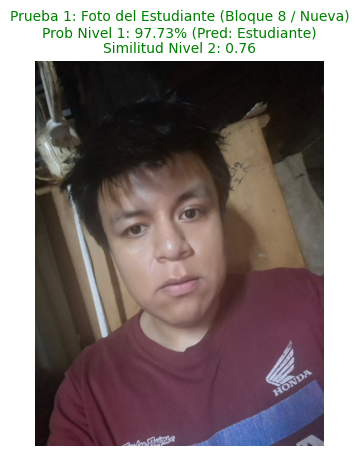

Archivo evaluado: fs.jpeg
  - Nivel 1 Prob. Estudiante: 97.73% | Umbral: 0.90 -> Estudiante
  - Nivel 2 Similitud Coseno: 0.7562 -> Coincide con Estudiante
  - Resultado Evaluado: APROBADO [OK] -> Puntos: 2/2



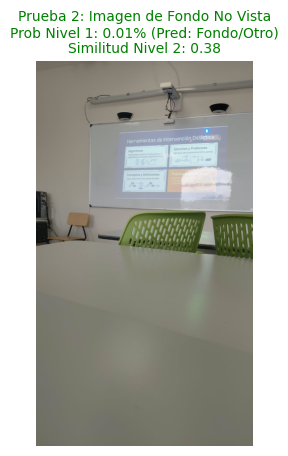

Archivo evaluado: test2_unseen_background.jpeg
  - Nivel 1 Prob. Estudiante: 0.01% | Umbral: 0.90 -> Fondo/Otro
  - Nivel 2 Similitud Coseno: 0.3753 -> No Coincide
  - Resultado Evaluado: APROBADO [OK] -> Puntos: 2/2



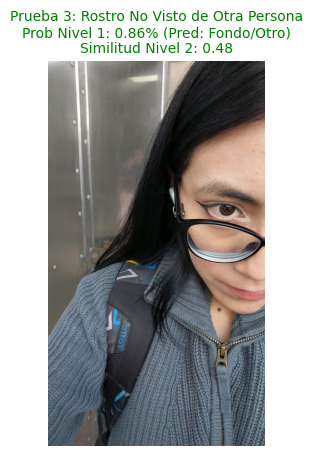

Archivo evaluado: test3_unseen_other_person.jpeg
  - Nivel 1 Prob. Estudiante: 0.86% | Umbral: 0.90 -> Fondo/Otro
  - Nivel 2 Similitud Coseno: 0.4805 -> No Coincide
  - Resultado Evaluado: APROBADO [OK] -> Puntos: 6/6

 PUNTAJE TOTAL FINAL OBTENIDO: 10 / 10 PUNTOS


In [60]:
# ==============================================================================
# CONFIGURACIÓN DE ARCHIVOS DE PRUEBA (Edita tus rutas o imágenes aquí):
# ==============================================================================
TEST_1_IMAGE = "fs.jpeg"                      # Prueba 1: Foto del estudiante (ej. 'fs.jpeg' tomada en Bloque 8)
TEST_2_IMAGE = "test2_unseen_background.jpeg"  # Prueba 2: Imagen de fondo sin personas
TEST_3_IMAGE = "test3_unseen_other_person.jpeg" # Prueba 3: Rostro no visto de otra persona
# ==============================================================================

def resolve_test_file(filename_or_prefix):
    if not os.path.exists(test_dir):
        return None
    exact_path = os.path.join(test_dir, filename_or_prefix)
    if os.path.exists(exact_path):
        return exact_path
    for fn in os.listdir(test_dir):
        if fn.lower().startswith(filename_or_prefix.lower()):
            return os.path.join(test_dir, fn)
    return None

def evaluate_test_image(file_setting, test_title, expected_class, points):
    test_path = resolve_test_file(file_setting)
    if test_path is None or not os.path.exists(test_path):
        print(f"Error: No se encontró la imagen '{file_setting}' en {test_dir}")
        return False, 0
        
    img = cv2.imread(test_path)
    proc = extract_face_or_image(img, target_size=(128, 128)).astype('float32')
    x_in = np.expand_dims(proc, axis=0)
    
    # Predicción Nivel 1 (Clasificador Neuronal Fine-Tuned)
    prob = model.predict(x_in, verbose=0)[0][0]
    pred_class = 1 if prob >= best_threshold else 0
    pred_label = "Estudiante" if pred_class == 1 else "Fondo/Otro"
    expected_label = "Estudiante" if expected_class == 1 else "Fondo/Otro"
    
    # Predicción Nivel 2 (Similitud Coseno por Embeddings)
    sim, emb_is_student = verify_face_embedding(proc)
    
    success = (pred_class == expected_class)
    earned_points = points if success else 0
    
    plt.figure(figsize=(5, 5))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    color = 'green' if success else 'red'
    plt.title(
        f"{test_title}\nProb Nivel 1: {prob:.2%} (Pred: {pred_label})\nSimilitud Nivel 2: {sim:.2f}",
        color=color,
        fontsize=10
    )
    plt.axis('off')
    plt.show()
    
    print(f"Archivo evaluado: {os.path.basename(test_path)}")
    print(f"  - Nivel 1 Prob. Estudiante: {prob:.2%} | Umbral: {best_threshold:.2f} -> {pred_label}")
    print(f"  - Nivel 2 Similitud Coseno: {sim:.4f} -> {'Coincide con Estudiante' if emb_is_student else 'No Coincide'}")
    print(f"  - Resultado Evaluado: {'APROBADO [OK]' if success else 'REPROBADO [X]'} -> Puntos: {earned_points}/{points}\n")
    return success, earned_points

print("=== EVALUACIÓN DE LAS 3 PRUEBAS EXIGIDAS ===\n")
p1_ok, p1_pts = evaluate_test_image(TEST_1_IMAGE, 'Prueba 1: Foto del Estudiante (Bloque 8 / Nueva)', 1, 2)
p2_ok, p2_pts = evaluate_test_image(TEST_2_IMAGE, 'Prueba 2: Imagen de Fondo No Vista', 0, 2)
p3_ok, p3_pts = evaluate_test_image(TEST_3_IMAGE, 'Prueba 3: Rostro No Visto de Otra Persona', 0, 6)

total_pts = p1_pts + p2_pts + p3_pts
print(f"==================================================")
print(f" PUNTAJE TOTAL FINAL OBTENIDO: {total_pts} / 10 PUNTOS")
print(f"==================================================")

## 12. Guardar y Exportar el Modelo Completo

In [ ]:
model.save('modelo_clasificacion_estudiante_avanzado.keras')
print("Modelo optimizado guardado exitosamente como 'modelo_clasificacion_estudiante_avanzado.keras'")

loaded_model = keras.models.load_model('modelo_clasificacion_estudiante_avanzado.keras')
print("Verificación completada: El modelo guardado se carga y funciona correctamente.")

## 13. Bloque de Predicción Interactiva para Cualquier Foto Personalizada
**Instrucciones:** Cambia la variable `RUTA_FOTO_A_EVALUAR` a continuación por la ruta de cualquier imagen que desees evaluar. El bloque ejecutará automáticamente las dos arquitecturas del cuaderno (Red Neuronal MobileNetV2 y Sistema de Embeddings Coseno).

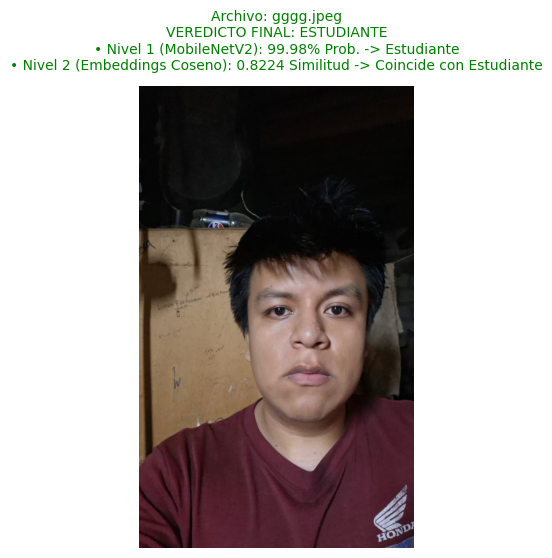

 REPORTE DE PREDICCIÓN CON AMBAS ARQUITECTURAS
 Ruta Evaluada: C:\Users\User\Desktop\deber\Dataset\Test_Cases\gggg.jpeg
 [1] Nivel 1 - Red Neuronal Convolucional (MobileNetV2 Fine-Tuned):
     - Probabilidad Estudiante: 99.98%
     - Umbral de Decisión Óptimo: 0.90
     - Clasificación: Estudiante
 [2] Nivel 2 - Sistema de Embeddings (Similitud Coseno vs Prototipo):
     - Similitud Coseno: 0.8224
     - Umbral de Similitud: 0.60
     - Resultado Embeddings: Coincide con Estudiante
 >>> VEREDICTO FINAL: ESTUDIANTE <<<



In [63]:
# ==============================================================================
# BLOQUE INTERACTIVO: INGRESA LA RUTA DE TU FOTO AQUÍ
# ==============================================================================
RUTA_FOTO_A_EVALUAR = r"C:\Users\User\Desktop\deber\Dataset\Test_Cases\gggg.jpeg"
# ==============================================================================

def predecir_foto_personalizada(ruta_foto):
    if not os.path.exists(ruta_foto):
        print(f"Error: El archivo '{ruta_foto}' no fue encontrado. Revisa la ruta.")
        return
    
    img = cv2.imread(ruta_foto)
    if img is None:
        print(f"Error: No se pudo leer la imagen '{ruta_foto}'.")
        return
        
    # Extracción de rostro con margen contextual
    crop_128 = extract_face_or_image(img, target_size=(128, 128)).astype('float32')
    x_in = np.expand_dims(crop_128, axis=0)
    
    # 1. Arquitectura Nivel 1: Clasificador Neuronal MobileNetV2 Fine-Tuned
    prob_estudiante = model.predict(x_in, verbose=0)[0][0]
    pred_nivel_1 = 1 if prob_estudiante >= best_threshold else 0
    label_nivel_1 = "Estudiante" if pred_nivel_1 == 1 else "Fondo / Otra Persona"
    
    # 2. Arquitectura Nivel 2: Verificador por Embeddings (Similitud Coseno)
    similitud_coseno, es_estudiante_emb = verify_face_embedding(crop_128, threshold_sim=0.60)
    label_nivel_2 = "Coincide con Estudiante" if es_estudiante_emb else "No Coincide (Fondo/Otro)"
    
    # Veredicto Final Combinado
    veredicto_final = "ESTUDIANTE" if pred_nivel_1 == 1 else "FONDO / OTRA PERSONA"
    color_titulo = 'green' if pred_nivel_1 == 1 else 'red'
    
    # Visualización Gráfica
    plt.figure(figsize=(6, 6))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(
        f"Archivo: {os.path.basename(ruta_foto)}\n"
        f"VEREDICTO FINAL: {veredicto_final}\n"
        f"• Nivel 1 (MobileNetV2): {prob_estudiante:.2%} Prob. -> {label_nivel_1}\n"
        f"• Nivel 2 (Embeddings Coseno): {similitud_coseno:.4f} Similitud -> {label_nivel_2}",
        color=color_titulo,
        fontsize=10,
        pad=12
    )
    plt.axis('off')
    plt.show()
    
    # Impresión en Consola
    print("=" * 65)
    print(f" REPORTE DE PREDICCIÓN CON AMBAS ARQUITECTURAS")
    print("=" * 65)
    print(f" Ruta Evaluada: {ruta_foto}")
    print(f" [1] Nivel 1 - Red Neuronal Convolucional (MobileNetV2 Fine-Tuned):")
    print(f"     - Probabilidad Estudiante: {prob_estudiante:.2%}")
    print(f"     - Umbral de Decisión Óptimo: {best_threshold:.2f}")
    print(f"     - Clasificación: {label_nivel_1}")
    print(f" [2] Nivel 2 - Sistema de Embeddings (Similitud Coseno vs Prototipo):")
    print(f"     - Similitud Coseno: {similitud_coseno:.4f}")
    print(f"     - Umbral de Similitud: 0.60")
    print(f"     - Resultado Embeddings: {label_nivel_2}")
    print("=" * 65)
    print(f" >>> VEREDICTO FINAL: {veredicto_final} <<<")
    print("=" * 65 + "\n")

predecir_foto_personalizada(RUTA_FOTO_A_EVALUAR)